
# Modelling.ipynb — KKBox Churn (baseline from original Processing pipeline)

Mục tiêu của notebook:

1. Nạp dữ liệu đã xử lý từ `Processing.ipynb`
2. Chạy sanity check trước modelling
3. Train các baseline:
   - Logistic Regression
   - LightGBM
   - XGBoost
4. Đánh giá bằng:
   - ROC-AUC
   - PR-AUC
   - Log Loss
   - Precision / Recall / F1
5. Tune threshold theo business
6. Xuất prediction, importance, model artifact

> Lưu ý: notebook này **giữ nguyên output của Processing.ipynb trước**, chưa ép sang time-based validation mới. Mục tiêu là có baseline đầu tiên để so sánh.


In [1]:

# ===== 1. Imports =====
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt


In [2]:

# ===== 2. Paths =====
DATA_DIR = Path("Data")
ARTIFACT_DIR = Path("Artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True, parents=True)

TRAIN_X_PATH = DATA_DIR / "X_train.parquet"
VAL_X_PATH   = DATA_DIR / "X_val.parquet"
TRAIN_Y_PATH = DATA_DIR / "y_train.parquet"
VAL_Y_PATH   = DATA_DIR / "y_val.parquet"

for p in [TRAIN_X_PATH, VAL_X_PATH, TRAIN_Y_PATH, VAL_Y_PATH]:
    print(f"{p}: {'FOUND' if p.exists() else 'MISSING'}")


Data\X_train.parquet: FOUND
Data\X_val.parquet: FOUND
Data\y_train.parquet: FOUND
Data\y_val.parquet: FOUND


In [3]:

# ===== 3. Load data =====
if not all(p.exists() for p in [TRAIN_X_PATH, VAL_X_PATH, TRAIN_Y_PATH, VAL_Y_PATH]):
    raise FileNotFoundError(
        "Không tìm thấy parquet output từ Processing.ipynb. "
        "Hãy chạy Processing.ipynb trước hoặc sửa lại đường dẫn Data/."
    )

X_train = pd.read_parquet(TRAIN_X_PATH)
X_val   = pd.read_parquet(VAL_X_PATH)
y_train = pd.read_parquet(TRAIN_Y_PATH).iloc[:, 0]
y_val   = pd.read_parquet(VAL_Y_PATH).iloc[:, 0]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

display(X_train.head())


X_train: (776768, 32)
X_val  : (194192, 32)
y_train: (776768,)
y_val  : (194192,)


,city,bd,gender,registered_via,n_txns,cancel_rate,auto_renew_rate,avg_plan_days,share_30d,zero_paid_rate,...,txn_recency_ratio,activity_freshness,arpu,engagement_score,passive_user,churn_risk_score,inactive_ratio,subscription_stability,cancel_pressure,activity_decay
476786,5,26.0,male,3,1.0,0.0,0.0,30.0,1.0,0.0,...,0.142857,NaN,0.098847,NaN,0,NaN,0.548600,0.0,0.0,NaN
689930,1,28.0,Unknown,7,1.0,0.0,1.0,30.0,1.0,0.0,...,0.052632,NaN,0.130473,NaN,0,NaN,0.874781,1.0,0.0,NaN
332397,1,28.0,Unknown,7,1.0,0.0,1.0,30.0,1.0,0.0,...,0.035714,0.002865,0.213467,2641.5,0,9.333333,0.001433,1.0,0.0,1.0
158772,12,25.0,female,3,2.0,0.0,1.0,30.0,1.0,0.0,...,1.000000,NaN,0.188727,NaN,0,NaN,0.632679,1.0,0.0,NaN
39054,1,28.0,Unknown,7,1.0,1.0,1.0,30.0,1.0,0.0,...,0.055556,NaN,0.051349,NaN,0,NaN,0.518154,0.0,17.0,NaN


In [4]:

# ===== 4. Sanity check =====
print("Target distribution:")
print("Train churn rate:", y_train.mean())
print("Val churn rate  :", y_val.mean())
print()

print("Missing values in X_train:")
display(X_train.isna().sum().sort_values(ascending=False).head(20))

print("Dtypes:")
display(X_train.dtypes.value_counts())


Target distribution:
Train churn rate: 0.08994191315811156
Val churn rate  : 0.08994191315811156

Missing values in X_train:


churn_risk_score            595887
activity_freshness          591019
activity_decay              591017
engagement_score            591017
arpu                        116532
inactive_ratio               88058
txn_recency_ratio            29916
subscription_stability       29916
cancel_pressure              29916
city                             0
gender                           0
bd                               0
n_txns                           0
cancel_rate                      0
auto_renew_rate                  0
registered_via                   0
total_secs_mean                  0
max_unique_songs_per_day         0
active_days                      0
last_gap_days                    0
dtype: int64

Dtypes:


float64     28
category     1
category     1
category     1
int64        1
Name: count, dtype: int64

In [5]:

# ===== 5. Detect feature types =====
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns    :", len(numeric_cols))
print("\nSample categorical columns:", categorical_cols[:15])
print("\nSample numeric columns:", numeric_cols[:15])


Number of categorical columns: 3
Number of numeric columns    : 29

Sample categorical columns: ['city', 'gender', 'registered_via']

Sample numeric columns: ['bd', 'n_txns', 'cancel_rate', 'auto_renew_rate', 'avg_plan_days', 'share_30d', 'zero_paid_rate', 'total_amount_paid', 'avg_discount_rate', 'last_gap_days', 'active_days', 'max_unique_songs_per_day', 'total_secs_mean', 'completion_ratio', 'early_skip_rate']



## 6. Helper functions


In [6]:

def evaluate_predictions(y_true, y_proba, threshold=0.5, model_name="model"):
    y_pred = (y_proba >= threshold).astype(int)
    metrics = {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    return metrics


def threshold_search(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "tn": tn, "fp": fp, "fn": fn, "tp": tp
        })
    return pd.DataFrame(rows)


def business_threshold_search(y_true, y_proba, value_saved=100, intervention_cost=10, thresholds=None):
    """
    value_saved: giá trị giữ lại được nếu cứu đúng 1 khách churn
    intervention_cost: chi phí can thiệp cho 1 khách được nhắm mục tiêu
    profit = TP * value_saved - (TP + FP) * intervention_cost
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = tp * value_saved - (tp + fp) * intervention_cost
        rows.append({
            "threshold": th,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "profit": profit,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)



## 7. Baseline 1 — Logistic Regression

Dùng làm benchmark dễ giải thích.  
Với categorical features, dùng One-Hot Encoding.


In [7]:

# ===== 7. Logistic Regression pipeline =====
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

print("Training Logistic Regression...")
logit_model.fit(X_train, y_train)

logit_val_proba = logit_model.predict_proba(X_val)[:, 1]
logit_metrics = evaluate_predictions(y_val, logit_val_proba, threshold=0.5, model_name="LogisticRegression")
pd.DataFrame([logit_metrics])


Training Logistic Regression...


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,LogisticRegression,0.5,0.965954,0.781681,0.250291,0.608013,0.871465,0.716282



## 8. Baseline 2 — LightGBM

Giữ đúng tinh thần top baseline của cuộc thi: boosting trên dữ liệu bảng là mũi nhọn.  
Ở đây dùng mã hóa category thành integer codes để LightGBM xử lý ổn định.


In [8]:

# ===== 8. Prepare data for tree models =====
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()

for col in categorical_cols:
    all_vals = pd.concat([X_train_tree[col], X_val_tree[col]], axis=0).astype("category")
    categories = all_vals.cat.categories
    X_train_tree[col] = pd.Categorical(X_train_tree[col], categories=categories).codes
    X_val_tree[col] = pd.Categorical(X_val_tree[col], categories=categories).codes

# fill numeric missing if any
for col in numeric_cols:
    med = X_train_tree[col].median()
    X_train_tree[col] = X_train_tree[col].fillna(med)
    X_val_tree[col] = X_val_tree[col].fillna(med)

print(X_train_tree.shape, X_val_tree.shape)
display(X_train_tree.head())


(776768, 32) (194192, 32)


,city,bd,gender,registered_via,n_txns,cancel_rate,auto_renew_rate,avg_plan_days,share_30d,zero_paid_rate,...,txn_recency_ratio,activity_freshness,arpu,engagement_score,passive_user,churn_risk_score,inactive_ratio,subscription_stability,cancel_pressure,activity_decay
476786,16,26.0,2,1,1.0,0.0,0.0,30.0,1.0,0.0,...,0.142857,0.001128,0.098847,2836.206025,0,13.000000,0.548600,0.0,0.0,0.076923
689930,0,28.0,0,3,1.0,0.0,1.0,30.0,1.0,0.0,...,0.052632,0.001128,0.130473,2836.206025,0,13.000000,0.874781,1.0,0.0,0.076923
332397,0,28.0,0,3,1.0,0.0,1.0,30.0,1.0,0.0,...,0.035714,0.002865,0.213467,2641.500000,0,9.333333,0.001433,1.0,0.0,1.000000
158772,3,25.0,1,1,2.0,0.0,1.0,30.0,1.0,0.0,...,1.000000,0.001128,0.188727,2836.206025,0,13.000000,0.632679,1.0,0.0,0.076923
39054,0,28.0,0,3,1.0,1.0,1.0,30.0,1.0,0.0,...,0.055556,0.001128,0.051349,2836.206025,0,13.000000,0.518154,0.0,17.0,0.076923


In [9]:

# ===== 9. Train LightGBM =====
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_child_samples=50,
    class_weight=None,
    scale_pos_weight=float(scale_pos_weight),
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM...")
lgb_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

lgb_val_proba = lgb_model.predict_proba(X_val_tree)[:, 1]
lgb_metrics = evaluate_predictions(y_val, lgb_val_proba, threshold=0.5, model_name="LightGBM")
pd.DataFrame([lgb_metrics])


Training LightGBM...
[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4402
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,LightGBM,0.5,0.987775,0.898174,0.125645,0.713985,0.931868,0.808504



## 9. Baseline 3 — XGBoost


In [10]:

# ===== 10. Train XGBoost =====
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=float(scale_pos_weight),
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    verbose=False
)

xgb_val_proba = xgb_model.predict_proba(X_val_tree)[:, 1]
xgb_metrics = evaluate_predictions(y_val, xgb_val_proba, threshold=0.5, model_name="XGBoost")
pd.DataFrame([xgb_metrics])


Training XGBoost...


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,XGBoost,0.5,0.98808,0.913716,0.137329,0.679995,0.936677,0.787959



## 10. Compare model results


In [11]:

results = pd.DataFrame([logit_metrics, lgb_metrics, xgb_metrics]).sort_values(
    by=["pr_auc", "roc_auc"], ascending=False
).reset_index(drop=True)

display(results)

results.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)
print("Saved:", ARTIFACT_DIR / "model_comparison.csv")


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,XGBoost,0.5,0.988080,0.913716,0.137329,0.679995,0.936677,0.787959
1,LightGBM,0.5,0.987775,0.898174,0.125645,0.713985,0.931868,0.808504
2,LogisticRegression,0.5,0.965954,0.781681,0.250291,0.608013,0.871465,0.716282


Saved: Artifacts\model_comparison.csv



## 11. Threshold tuning

Mặc định 0.5 không phải lúc nào cũng là ngưỡng tối ưu cho churn.  
Ta xem cả ngưỡng theo F1 và ngưỡng theo logic business.


In [12]:

# Choose best model by PR-AUC
model_name = results.iloc[0]["model"]
if model_name == "LogisticRegression":
    best_proba = logit_val_proba
elif model_name == "LightGBM":
    best_proba = lgb_val_proba
else:
    best_proba = xgb_val_proba

threshold_df = threshold_search(y_val, best_proba)
display(threshold_df)

best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
print("Best threshold by F1:")
print(best_f1_row)


,threshold,precision,recall,f1,tn,fp,fn,tp
0,0.05,0.249660,0.997309,0.399349,124374,52352,47,17419
1,0.10,0.396872,0.984885,0.565762,150584,26142,264,17202
2,0.15,0.448107,0.982137,0.615423,155599,21127,312,17154
3,0.20,0.461536,0.981049,0.627748,156735,19991,331,17135
4,0.25,0.474150,0.979274,0.638936,157757,18969,362,17104
5,0.30,0.495568,0.976182,0.657400,159371,17355,416,17050
6,0.35,0.521505,0.971201,0.678615,161162,15564,503,16963
7,0.40,0.565100,0.961926,0.711952,163796,12930,665,16801
8,0.45,0.620046,0.949559,0.750215,166563,10163,881,16585
9,0.50,0.679995,0.936677,0.787959,169027,7699,1106,16360


Best threshold by F1:
threshold         0.850000
precision         0.829044
recall            0.881541
f1                0.854487
tn           173551.000000
fp             3175.000000
fn             2069.000000
tp            15397.000000
Name: 16, dtype: float64


In [13]:

business_df = business_threshold_search(
    y_val, best_proba,
    value_saved=100,
    intervention_cost=10
)
display(business_df.sort_values("profit", ascending=False).head(10))

best_profit_row = business_df.sort_values("profit", ascending=False).iloc[0]
print("Best threshold by business profit:")
print(best_profit_row)


,threshold,tp,fp,fn,tn,profit,precision,recall,f1
10,0.55,16243,6521,1223,170205,1396660,0.713539,0.929978,0.807507
11,0.60,16137,5667,1329,171059,1395660,0.740094,0.923909,0.821849
9,0.50,16360,7699,1106,169027,1395410,0.679995,0.936677,0.787959
12,0.65,16051,5070,1415,171656,1393890,0.759955,0.918985,0.831938
8,0.45,16585,10163,881,166563,1391020,0.620046,0.949559,0.750215
13,0.70,15946,4573,1520,172153,1389410,0.777133,0.912974,0.839595
14,0.75,15849,4162,1617,172564,1384790,0.792014,0.907420,0.845799
7,0.40,16801,12930,665,163796,1382790,0.565100,0.961926,0.711952
15,0.80,15714,3752,1752,172974,1376740,0.807254,0.899691,0.850969
6,0.35,16963,15564,503,161162,1371030,0.521505,0.971201,0.678615


Best threshold by business profit:
threshold    5.500000e-01
tp           1.624300e+04
fp           6.521000e+03
fn           1.223000e+03
tn           1.702050e+05
profit       1.396660e+06
precision    7.135389e-01
recall       9.299782e-01
f1           8.075068e-01
Name: 10, dtype: float64


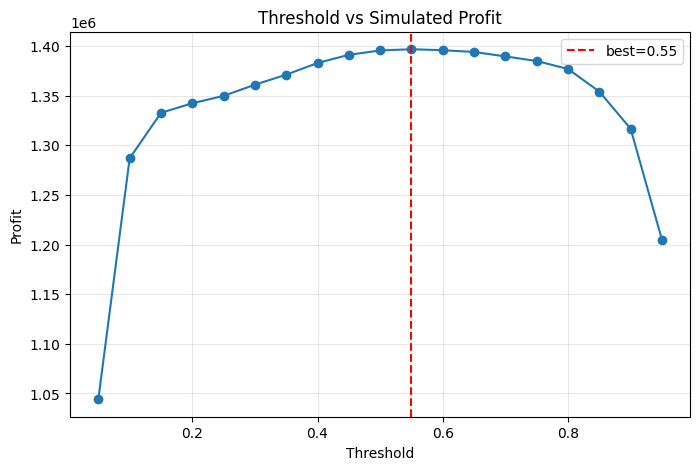

In [14]:

plt.figure(figsize=(8, 5))
plt.plot(business_df["threshold"], business_df["profit"], marker="o")
plt.axvline(best_profit_row["threshold"], color="red", linestyle="--", label=f"best={best_profit_row['threshold']:.2f}")
plt.title("Threshold vs Simulated Profit")
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 12. Feature importance


In [15]:

# LightGBM importance
if hasattr(lgb_model, "feature_importances_"):
    fi_lgb = pd.DataFrame({
        "feature": X_train_tree.columns,
        "importance": lgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(fi_lgb.head(30))
    fi_lgb.to_csv(ARTIFACT_DIR / "lightgbm_feature_importance.csv", index=False)


,feature,importance
12,last_gap_days,885
10,total_amount_paid,701
19,days_since_reg,409
24,arpu,355
3,registered_via,241
22,txn_recency_ratio,216
0,city,193
21,days_since_last_txn,171
4,n_txns,169
5,cancel_rate,110


In [16]:

# XGBoost importance
if hasattr(xgb_model, "feature_importances_"):
    fi_xgb = pd.DataFrame({
        "feature": X_train_tree.columns,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(fi_xgb.head(30))
    fi_xgb.to_csv(ARTIFACT_DIR / "xgboost_feature_importance.csv", index=False)


,feature,importance
8,share_30d,0.375806
6,auto_renew_rate,0.165500
30,cancel_pressure,0.115162
29,subscription_stability,0.112785
10,total_amount_paid,0.037678
4,n_txns,0.036913
5,cancel_rate,0.032975
12,last_gap_days,0.024342
7,avg_plan_days,0.019518
21,days_since_last_txn,0.016746



## 13. Save artifacts


In [17]:

joblib.dump(logit_model, ARTIFACT_DIR / "logistic_model.joblib")
joblib.dump(lgb_model, ARTIFACT_DIR / "lightgbm_model.joblib")
joblib.dump(xgb_model, ARTIFACT_DIR / "xgboost_model.joblib")

pred_df = pd.DataFrame({
    "y_true": y_val.values,
    "logit_proba": logit_val_proba,
    "lgb_proba": lgb_val_proba,
    "xgb_proba": xgb_val_proba
})
pred_df.to_parquet(ARTIFACT_DIR / "validation_predictions.parquet", index=False)

with open(ARTIFACT_DIR / "best_threshold_by_f1.json", "w", encoding="utf-8") as f:
    json.dump(best_f1_row.to_dict(), f, ensure_ascii=False, indent=2)

with open(ARTIFACT_DIR / "best_threshold_by_profit.json", "w", encoding="utf-8") as f:
    json.dump(best_profit_row.to_dict(), f, ensure_ascii=False, indent=2)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())


Artifacts saved to: C:\Users\Admin\.vscode\powz\Project2\Artifacts



## 14. Double check


In [18]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

print("Train duplicated rows:", X_train.duplicated().sum())
print("Val duplicated rows:", X_val.duplicated().sum())

print("Train index aligned:", (X_train.index == y_train.index).all())
print("Val index aligned:", (X_val.index == y_val.index).all())

(776768, 32) (776768,)
(194192, 32) (194192,)
Train duplicated rows: 263575
Val duplicated rows: 57412
Train index aligned: True
Val index aligned: True


In [19]:
summary = []
for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        summary.append({
            "feature": col,
            "train_mean": X_train[col].mean(),
            "val_mean": X_val[col].mean(),
            "train_std": X_train[col].std(),
            "val_std": X_val[col].std(),
            "mean_gap": abs(X_train[col].mean() - X_val[col].mean())
        })
drift_df = pd.DataFrame(summary).sort_values("mean_gap", ascending=False)
display(drift_df.head(20))

,feature,train_mean,val_mean,train_std,val_std,mean_gap
22,engagement_score,5787.990464,5855.602054,8420.784405,8643.125445,67.611590
12,total_secs_mean,1814.797112,1832.591922,5499.683563,5617.371416,17.794809
16,days_since_reg,1265.602202,1267.299255,1036.972758,1036.362849,1.697054
18,days_since_last_txn,53.349798,53.144311,190.714970,190.428656,0.205487
7,total_amount_paid,169.043977,169.206358,230.058464,228.599446,0.162381
17,days_since_last_activity,763.647277,763.791207,419.833575,419.742568,0.143930
9,last_gap_days,13.722375,13.579241,23.676641,22.368308,0.143134
11,max_unique_songs_per_day,7.307774,7.347759,20.708260,21.907691,0.039985
4,avg_plan_days,32.365208,32.398889,31.556018,31.760900,0.033681
24,churn_risk_score,13.610008,13.639500,7.809197,7.918485,0.029492


In [20]:
tmp = X_train.copy()
tmp["target"] = y_train.values

corrs = []
for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        try:
            corr = tmp[[col, "target"]].corr().iloc[0,1]
            corrs.append({"feature": col, "corr_with_target": corr})
        except:
            pass

corr_df = pd.DataFrame(corrs).sort_values("corr_with_target", ascending=False)
display(corr_df.head(20))
display(corr_df.tail(20))

,feature,corr_with_target
18,days_since_last_txn,0.507204
27,cancel_pressure,0.389773
2,cancel_rate,0.365852
4,avg_plan_days,0.262757
7,total_amount_paid,0.246026
6,zero_paid_rate,0.162670
24,churn_risk_score,0.122660
21,arpu,0.114606
9,last_gap_days,0.104611
8,avg_discount_rate,0.072962


,feature,corr_with_target
8,avg_discount_rate,0.072962
1,n_txns,0.032624
25,inactive_ratio,0.020137
17,days_since_last_activity,0.018946
20,activity_freshness,0.010445
16,days_since_reg,0.005671
22,engagement_score,0.000901
23,passive_user,-0.003134
14,early_skip_rate,-0.008785
11,max_unique_songs_per_day,-0.009121


In [21]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lgb_model, X_val_tree, y_val,
    n_repeats=5,
    random_state=42,
    scoring="average_precision"
)

perm_df = pd.DataFrame({
    "feature": X_val_tree.columns,
    "perm_importance": perm.importances_mean
}).sort_values("perm_importance", ascending=False)

display(perm_df.head(20))

,feature,perm_importance
8,share_30d,0.286829
10,total_amount_paid,0.077149
30,cancel_pressure,0.070124
12,last_gap_days,0.056060
6,auto_renew_rate,0.051253
4,n_txns,0.043971
29,subscription_stability,0.042233
7,avg_plan_days,0.037574
5,cancel_rate,0.029770
22,txn_recency_ratio,0.006987


In [22]:
missing_train = X_train.isna().mean().sort_values(ascending=False)
missing_val = X_val.isna().mean().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "train_missing_ratio": missing_train,
    "val_missing_ratio": missing_val
}).sort_values("train_missing_ratio", ascending=False)

display(missing_df.head(30))

,train_missing_ratio,val_missing_ratio
churn_risk_score,0.767136,0.767344
activity_freshness,0.760869,0.761015
activity_decay,0.760867,0.761010
engagement_score,0.760867,0.761010
arpu,0.150022,0.149646
inactive_ratio,0.113365,0.112955
txn_recency_ratio,0.038513,0.038446
subscription_stability,0.038513,0.038446
cancel_pressure,0.038513,0.038446
city,0.000000,0.000000


In [23]:
seeds = [13, 42, 77, 123, 2025]
rows = []

for seed in seeds:
    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=float(scale_pos_weight),
        random_state=seed,
        n_jobs=-1
    )
    model.fit(X_train_tree, y_train)
    proba = model.predict_proba(X_val_tree)[:, 1]
    rows.append(evaluate_predictions(y_val, proba, threshold=0.5, model_name=f"LGB_seed_{seed}"))

seed_df = pd.DataFrame(rows)
display(seed_df)

[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022197 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4427
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344
[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4402
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 32
[LightGBM] [In

,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,LGB_seed_13,0.5,0.988806,0.920352,0.128533,0.702441,0.935704,0.802465
1,LGB_seed_42,0.5,0.988835,0.920379,0.128504,0.701553,0.936047,0.802011
2,LGB_seed_77,0.5,0.988857,0.920340,0.128527,0.703472,0.934902,0.802842
3,LGB_seed_123,0.5,0.988882,0.920582,0.128384,0.704046,0.936391,0.803764
4,LGB_seed_2025,0.5,0.988848,0.920535,0.128501,0.702906,0.936162,0.802937


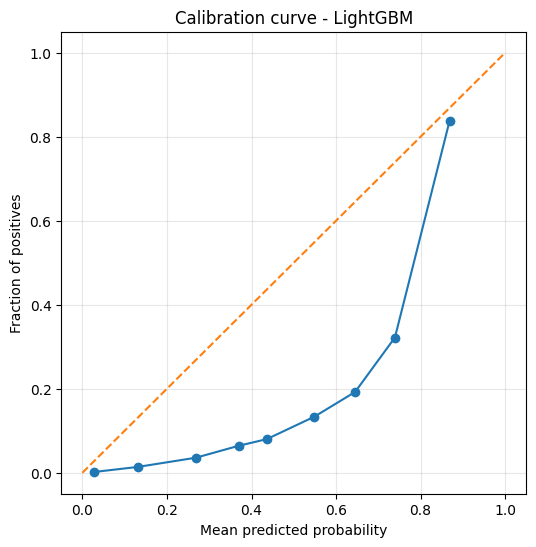

In [24]:
from sklearn.calibration import calibration_curve

proba = lgb_val_proba
frac_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve - LightGBM")
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
audit_df = pd.DataFrame({
    "y_true": y_val.values,
    "proba": lgb_val_proba
})

audit_df["decile"] = pd.qcut(audit_df["proba"], 10, labels=False, duplicates="drop")
decile_perf = audit_df.groupby("decile").agg(
    n=("y_true", "size"),
    churn_rate=("y_true", "mean"),
    avg_proba=("proba", "mean")
).reset_index()

display(decile_perf)

,decile,n,churn_rate,avg_proba
0,0,21738,0.000000,0.012033
1,1,21558,0.000000,0.012288
2,2,15353,0.000000,0.012400
3,3,19217,0.000052,0.012699
4,4,20535,0.000049,0.014152
5,5,18158,0.000826,0.024278
6,6,19504,0.004563,0.058161
7,7,19290,0.010161,0.086868
8,8,19422,0.074091,0.379479
9,9,19417,0.809857,0.861907


In [26]:
val_audit = X_val.copy()
val_audit["y_true"] = y_val.values
val_audit["proba"] = lgb_val_proba
val_audit["pred"] = (val_audit["proba"] >= 0.5).astype(int)

group_perf = val_audit.groupby("registered_via").apply(
    lambda g: pd.Series({
        "n": len(g),
        "actual_churn": g["y_true"].mean(),
        "pred_churn": g["pred"].mean()
    })
).reset_index()

display(group_perf)

,registered_via,n,actual_churn,pred_churn
0,13,666.0,0.088589,0.114114
1,3,21388.0,0.174070,0.231391
2,4,10534.0,0.228308,0.313651
3,7,92478.0,0.044681,0.059603
4,9,47191.0,0.126422,0.160921
5,Unknown,21935.0,0.053841,0.062047


In [27]:
top5 = ["last_gap_days", "days_since_last_txn", "cancel_rate", "auto_renew_rate", "total_amount_paid"]
top5 = [c for c in top5 if c in X_train_tree.columns]

model_top5 = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model_top5.fit(X_train_tree[top5], y_train)
proba_top5 = model_top5.predict_proba(X_val_tree[top5])[:, 1]
print(evaluate_predictions(y_val, proba_top5, threshold=0.5, model_name="LGB_top5"))

[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 679
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344
{'model': 'LGB_top5', 'threshold': 0.5, 'roc_auc': np.float64(0.9855396639544244), 'pr_auc': np.float64(0.8870970859625659), 'log_loss': 0.0767511564080309, 'precision': 0.8437063132584018, 'recall': 0.863849765258216, 'f1': 0.8536592265693513}


=== BASIC SHAPES ===
X_train: (776768, 32)
X_val  : (194192, 32)
y_train: (776768,)  churn_rate = 0.08994191315811156
y_val  : (194192,)  churn_rate = 0.08994191315811156

=== FEATURE TYPES ===
Categorical: 3
Numeric    : 29

=== TOP NUMERIC DRIFT BY ABS MEAN GAP ===


,feature,train_mean,val_mean,train_std,val_std,train_missing,val_missing,mean_gap_abs,std_gap_abs
22,engagement_score,5787.990464,5855.602054,8420.784405,8643.125445,0.760867,0.761010,67.611590,222.341041
12,total_secs_mean,1814.797112,1832.591922,5499.683563,5617.371416,0.000000,0.000000,17.794809,117.687853
16,days_since_reg,1265.602202,1267.299255,1036.972758,1036.362849,0.000000,0.000000,1.697054,0.609909
18,days_since_last_txn,53.349798,53.144311,190.714970,190.428656,0.000000,0.000000,0.205487,0.286314
7,total_amount_paid,169.043977,169.206358,230.058464,228.599446,0.000000,0.000000,0.162381,1.459018
17,days_since_last_activity,763.647277,763.791207,419.833575,419.742568,0.000000,0.000000,0.143930,0.091006
9,last_gap_days,13.722375,13.579241,23.676641,22.368308,0.000000,0.000000,0.143134,1.308334
11,max_unique_songs_per_day,7.307774,7.347759,20.708260,21.907691,0.000000,0.000000,0.039985,1.199432
4,avg_plan_days,32.365208,32.398889,31.556018,31.760900,0.000000,0.000000,0.033681,0.204882
24,churn_risk_score,13.610008,13.639500,7.809197,7.918485,0.767136,0.767344,0.029492,0.109288


=== PSI FOR NUMERIC FEATURES ===


,feature,psi
24,churn_risk_score,3.094639e-04
20,activity_freshness,2.950342e-04
22,engagement_score,2.289711e-04
28,activity_decay,1.892591e-04
25,inactive_ratio,1.116412e-04
16,days_since_reg,8.028952e-05
9,last_gap_days,6.786734e-05
19,txn_recency_ratio,1.923730e-05
21,arpu,1.620767e-05
18,days_since_last_txn,1.615451e-05


=== PSI FLAG COUNTS ===


...

,dataset,roc_auc,pr_auc,log_loss
0,train,0.988278,0.901743,0.124189
1,val,0.987775,0.898174,0.125645


ROC-AUC gap: 0.000503
PR-AUC gap : 0.003569
- Train và validation metric rất gần nhau.
  -> có thể là model rất ổn, hoặc validation đang hơi dễ/êm.

=== DECILE COMPARISON (if model available) ===
Train decile:


,decile,n,churn_rate,avg_proba
0,0,87291,0.000011,0.012032
1,1,86682,0.000000,0.012287
2,2,62042,0.000016,0.012400
3,3,77118,0.000000,0.012700
4,4,81815,0.000012,0.014146
5,5,72414,0.000787,0.024205
6,6,76401,0.003900,0.057881
7,7,77663,0.009863,0.086202
8,8,77727,0.073990,0.374846
9,9,77615,0.811557,0.860828


Validation decile:


,decile,n,churn_rate,avg_proba
0,0,21738,0.000000,0.012033
1,1,21558,0.000000,0.012288
2,2,15353,0.000000,0.012400
3,3,19217,0.000052,0.012699
4,4,20535,0.000049,0.014152
5,5,18158,0.000826,0.024278
6,6,19504,0.004563,0.058161
7,7,19290,0.010161,0.086868
8,8,19422,0.074091,0.379479
9,9,19417,0.809857,0.861907


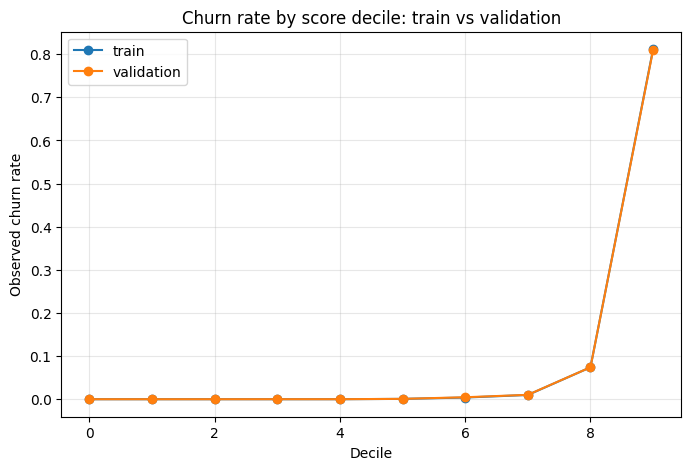


=== FINAL AUDIT SUMMARY ===
- Target rate gap: 0.000000
- Shared fingerprint ratio vs val unique: 0.1100
- Train-vs-val classifier AUC: 0.497358
\nQuick interpretation:
- Target rate giữa train và val khá giống nhau.
- Có mức overlap vừa phải giữa train và val.
- Train-vs-val classifier khó phân biệt hai tập -> validation có thể khá dễ.
\nKết luận nên đọc cùng với:
- metric gap train vs val
- PSI
- decile comparison
- duplicate/shared pattern analysis


In [28]:
# =========================
# FULL VALIDATION DIFFICULTY AUDIT
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# -------------------------
# 0. Basic checks
# -------------------------
print("=== BASIC SHAPES ===")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape, " churn_rate =", float(y_train.mean()))
print("y_val  :", y_val.shape,   " churn_rate =", float(y_val.mean()))
print()

# -------------------------
# 1. Feature type detection
# -------------------------
categorical_cols_audit = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols_audit = [c for c in X_train.columns if c not in categorical_cols_audit]

print("=== FEATURE TYPES ===")
print("Categorical:", len(categorical_cols_audit))
print("Numeric    :", len(numeric_cols_audit))
print()

# -------------------------
# 2. Distribution summary for numeric features
# -------------------------
dist_rows = []
for col in numeric_cols_audit:
    train_s = X_train[col]
    val_s = X_val[col]
    dist_rows.append({
        "feature": col,
        "train_mean": train_s.mean(),
        "val_mean": val_s.mean(),
        "train_std": train_s.std(),
        "val_std": val_s.std(),
        "train_missing": train_s.isna().mean(),
        "val_missing": val_s.isna().mean(),
        "mean_gap_abs": abs(train_s.mean() - val_s.mean()),
        "std_gap_abs": abs(train_s.std() - val_s.std())
    })

dist_df = pd.DataFrame(dist_rows).sort_values("mean_gap_abs", ascending=False)

print("=== TOP NUMERIC DRIFT BY ABS MEAN GAP ===")
display(dist_df.head(20))

# -------------------------
# 3. PSI calculation
# -------------------------
def calculate_psi(expected, actual, buckets=10):
    """
    PSI for numeric arrays.
    expected: train
    actual: validation
    """
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    # if too few unique values, skip quantile binning safely
    if expected.nunique() < 5 or actual.nunique() < 5:
        return np.nan

    breakpoints = np.unique(np.nanquantile(expected, np.linspace(0, 1, buckets + 1)))
    if len(breakpoints) < 3:
        return np.nan

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    expected_perc = expected_bins.value_counts(normalize=True, sort=False)
    actual_perc = actual_bins.value_counts(normalize=True, sort=False)

    # align index
    actual_perc = actual_perc.reindex(expected_perc.index, fill_value=0)

    # avoid zero
    expected_perc = expected_perc.replace(0, 1e-6)
    actual_perc = actual_perc.replace(0, 1e-6)

    psi = np.sum((actual_perc - expected_perc) * np.log(actual_perc / expected_perc))
    return float(psi)

psi_rows = []
for col in numeric_cols_audit:
    psi_rows.append({
        "feature": col,
        "psi": calculate_psi(X_train[col], X_val[col], buckets=10)
    })

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)

print("=== PSI FOR NUMERIC FEATURES ===")
display(psi_df.head(20))

# PSI quick interpretation
def psi_flag(x):
    if pd.isna(x):
        return "NA"
    elif x < 0.10:
        return "stable"
    elif x < 0.25:
        return "moderate drift"
    else:
        return "high drift"

psi_df["psi_flag"] = psi_df["psi"].apply(psi_flag)

print("=== PSI FLAG COUNTS ===")
display(psi_df["psi_flag"].value_counts(dropna=False))

# -------------------------
# 4. Shared fingerprint check
# -------------------------
# fill temporarily for hashing
X_train_hashable = X_train.copy()
X_val_hashable = X_val.copy()

for col in X_train_hashable.columns:
    if col in categorical_cols_audit:
        X_train_hashable[col] = X_train_hashable[col].astype(str).fillna("__MISSING__")
        X_val_hashable[col] = X_val_hashable[col].astype(str).fillna("__MISSING__")
    else:
        X_train_hashable[col] = X_train_hashable[col].replace([np.inf, -np.inf], np.nan).fillna(-999999)
        X_val_hashable[col] = X_val_hashable[col].replace([np.inf, -np.inf], np.nan).fillna(-999999)

train_hash = pd.util.hash_pandas_object(X_train_hashable, index=False)
val_hash = pd.util.hash_pandas_object(X_val_hashable, index=False)

shared = np.intersect1d(train_hash.values, val_hash.values)

print("=== SHARED FINGERPRINTS ===")
print("Train unique fingerprints :", train_hash.nunique())
print("Val unique fingerprints   :", val_hash.nunique())
print("Shared fingerprints count :", len(shared))
print("Shared / val unique       :", round(len(shared) / max(val_hash.nunique(), 1), 4))
print()

# -------------------------
# 5. Train-vs-val classifier
# -------------------------
print("=== TRAIN-vs-VAL CLASSIFIER AUDIT ===")

X_audit_all = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
z_audit = np.array([0] * len(X_train) + [1] * len(X_val))  # 0=train, 1=val

cat_cols_tv = X_audit_all.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols_tv = [c for c in X_audit_all.columns if c not in cat_cols_tv]

num_pipe_tv = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe_tv = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre_tv = ColumnTransformer([
    ("num", num_pipe_tv, num_cols_tv),
    ("cat", cat_pipe_tv, cat_cols_tv)
])

tv_model = Pipeline([
    ("preprocess", pre_tv),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

X_tv_train, X_tv_test, z_tv_train, z_tv_test = train_test_split(
    X_audit_all, z_audit, test_size=0.2, stratify=z_audit, random_state=42
)

tv_model.fit(X_tv_train, z_tv_train)
z_proba = tv_model.predict_proba(X_tv_test)[:, 1]
tv_auc = roc_auc_score(z_tv_test, z_proba)

print("Train-vs-Val classifier ROC-AUC:", round(tv_auc, 6))
print("Interpretation:")
if tv_auc < 0.55:
    print("- Train và validation rất giống nhau -> validation có thể khá dễ / quá êm.")
elif tv_auc < 0.65:
    print("- Có khác biệt nhẹ giữa train và validation -> mức hợp lý.")
else:
    print("- Train và validation khác nhau khá rõ -> validation khó hơn hoặc có drift.")
print()

# -------------------------
# 6. Train vs Val metric gap for current model (if available)
# -------------------------
print("=== MODEL TRAIN-vs-VAL GAP ===")

if ("lgb_model" in globals()) and ("X_train_tree" in globals()) and ("X_val_tree" in globals()):
    train_proba = lgb_model.predict_proba(X_train_tree)[:, 1]
    val_proba   = lgb_model.predict_proba(X_val_tree)[:, 1]

    metric_gap_df = pd.DataFrame([{
        "dataset": "train",
        "roc_auc": roc_auc_score(y_train, train_proba),
        "pr_auc": average_precision_score(y_train, train_proba),
        "log_loss": log_loss(y_train, train_proba)
    }, {
        "dataset": "val",
        "roc_auc": roc_auc_score(y_val, val_proba),
        "pr_auc": average_precision_score(y_val, val_proba),
        "log_loss": log_loss(y_val, val_proba)
    }])

    display(metric_gap_df)

    train_roc = metric_gap_df.loc[metric_gap_df["dataset"]=="train", "roc_auc"].iloc[0]
    val_roc   = metric_gap_df.loc[metric_gap_df["dataset"]=="val", "roc_auc"].iloc[0]
    train_pr  = metric_gap_df.loc[metric_gap_df["dataset"]=="train", "pr_auc"].iloc[0]
    val_pr    = metric_gap_df.loc[metric_gap_df["dataset"]=="val", "pr_auc"].iloc[0]

    print("ROC-AUC gap:", round(train_roc - val_roc, 6))
    print("PR-AUC gap :", round(train_pr - val_pr, 6))

    if abs(train_roc - val_roc) < 0.005 and abs(train_pr - val_pr) < 0.01:
        print("- Train và validation metric rất gần nhau.")
        print("  -> có thể là model rất ổn, hoặc validation đang hơi dễ/êm.")
    elif (train_roc - val_roc) > 0.03 or (train_pr - val_pr) > 0.03:
        print("- Validation yếu hơn train đáng kể.")
        print("  -> có thể overfit, hoặc validation khó hơn.")
    else:
        print("- Khoảng cách train-val ở mức vừa phải, khá hợp lý.")
else:
    print("Không tìm thấy lgb_model / X_train_tree / X_val_tree trong notebook.")
    print("Bỏ qua phần train-vs-val model metric gap.")
print()

# -------------------------
# 7. Decile comparison for current model (if available)
# -------------------------
print("=== DECILE COMPARISON (if model available) ===")

def decile_table(y_true, proba, q=10):
    df = pd.DataFrame({"y": np.array(y_true), "p": np.array(proba)})
    df["decile"] = pd.qcut(df["p"], q=q, labels=False, duplicates="drop")
    out = df.groupby("decile").agg(
        n=("y", "size"),
        churn_rate=("y", "mean"),
        avg_proba=("p", "mean")
    ).reset_index()
    return out

if ("lgb_model" in globals()) and ("X_train_tree" in globals()) and ("X_val_tree" in globals()):
    train_proba = lgb_model.predict_proba(X_train_tree)[:, 1]
    val_proba   = lgb_model.predict_proba(X_val_tree)[:, 1]

    train_decile = decile_table(y_train, train_proba, q=10)
    val_decile   = decile_table(y_val, val_proba, q=10)

    print("Train decile:")
    display(train_decile)

    print("Validation decile:")
    display(val_decile)

    plt.figure(figsize=(8,5))
    plt.plot(train_decile["decile"], train_decile["churn_rate"], marker="o", label="train")
    plt.plot(val_decile["decile"], val_decile["churn_rate"], marker="o", label="validation")
    plt.title("Churn rate by score decile: train vs validation")
    plt.xlabel("Decile")
    plt.ylabel("Observed churn rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Không tìm thấy model/proba input để chạy decile comparison.")
print()

# -------------------------
# 8. Final audit summary
# -------------------------
print("=== FINAL AUDIT SUMMARY ===")

# quick summary variables
target_gap = abs(float(y_train.mean()) - float(y_val.mean()))
shared_ratio = len(shared) / max(val_hash.nunique(), 1)

print(f"- Target rate gap: {target_gap:.6f}")
print(f"- Shared fingerprint ratio vs val unique: {shared_ratio:.4f}")
print(f"- Train-vs-val classifier AUC: {tv_auc:.6f}")

print("\\nQuick interpretation:")
if target_gap < 0.01:
    print("- Target rate giữa train và val khá giống nhau.")
else:
    print("- Target rate chênh đáng kể, cần cảnh giác drift của validation.")

if shared_ratio > 0.20:
    print("- Shared fingerprint ratio khá cao -> validation có thể hơi dễ / quá giống train.")
elif shared_ratio > 0.05:
    print("- Có mức overlap vừa phải giữa train và val.")
else:
    print("- Overlap thấp, validation độc lập hơn.")

if tv_auc < 0.55:
    print("- Train-vs-val classifier khó phân biệt hai tập -> validation có thể khá dễ.")
elif tv_auc < 0.65:
    print("- Train-vs-val classifier cho thấy khác biệt nhẹ -> validation ở mức vừa phải.")
else:
    print("- Train-vs-val classifier phân biệt tốt -> validation khó hơn hoặc có drift rõ.")

print("\\nKết luận nên đọc cùng với:")
print("- metric gap train vs val")
print("- PSI")
print("- decile comparison")
print("- duplicate/shared pattern analysis")